<a href="https://colab.research.google.com/github/sprucesunday777/laptop-price-prediction/blob/main/Final1_Laptop_Price_Prediction_by_nsisong_sunday.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 Laptop Price Prediction
**Dataset:** 1,303 laptops · 12 raw features → 17 engineered features  
**Goal:** Predict laptop price from hardware specifications  
**Models:** Linear Regression · Decision Tree · Random Forest  

---

## 📦 Step 1 — Imports
Gather all tools before starting. pandas = table tool, numpy = maths, sklearn = ML models.

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported ✅')

Libraries imported ✅


 **What this cell does:** Imports every library the notebook needs. `os` talks to the file system, `kagglehub` pulls the dataset straight from Kaggle, `pandas`/`numpy` handle tables and numbers, `matplotlib`/`seaborn` draw charts, and `warnings` is silenced so the notebook output stays clean.

## 📥 Step 2 — Load Dataset
Download from Kaggle and load the CSV automatically.

In [2]:
path = kagglehub.dataset_download(
    'muhammadmusharraf444/laptop-specifications-and-price-prediction-dataset'
)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f'Shape: {df.shape}')
df.head()

100%|██████████| 24.4k/24.4k [00:00<00:00, 17.3MB/s]

Extracting files...


Shape: (1303, 12)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


 **What this cell does:** Downloads the Kaggle dataset (cached by Colab after the first run), finds the `.csv` file inside it, and loads it into a DataFrame called `df`.

**Result:** 1,303 rows × 12 columns. The preview shows the raw, messy columns we'll need to clean — e.g. `ScreenResolution` mixes panel type and resolution in one string, and `Ram`/`Weight` are text, not numbers.

## 🩺 Step 3 — Data Checks
Always run these 4 health checks first. Like a doctor's check-up before any treatment.

In [3]:
df.isnull().sum()  # count missing values per column

,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


**What this cell does:** Health check #1 — counts missing values per column.

**Result:** Zero missing values anywhere. Nothing to impute or drop.

In [4]:
df.duplicated().sum()  # count duplicate rows

np.int64(0)

 **What this cell does:** Health check #2 — counts fully duplicated rows.

**Result:** `0` duplicates, so no rows need to be removed.

In [5]:
df.info()  # dtypes and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


**What this cell does:** Health check #3 — `df.info()` shows the data type and non-null count for every column at a glance, confirming which columns are numeric (`Inches`, `Price`) versus text (`Ram`, `Weight`, `Cpu`, `Memory`, etc.) that will need cleaning.

In [6]:
df.describe()  # min, max, mean, std for numeric columns

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


**What this cell does:** Health check #4 — `df.describe()` gives summary statistics (min, max, mean, std) for the numeric columns.

**Result:** Prices range from 9,270 to 324,954, with a mean (59,870) noticeably higher than the median (52,054) — an early hint that price is skewed toward the high end.

## 🔍 Step 4 — Exploratory Data Analysis (EDA)

### Why EDA first?
EDA answers: *what does the data look like? What patterns exist?*  
The key finding here was that **Price is right-skewed** — most laptops are cheap, a few premium ones are very expensive. This violates Linear Regression's assumption of normally distributed residuals and tells us we need a log transformation later.



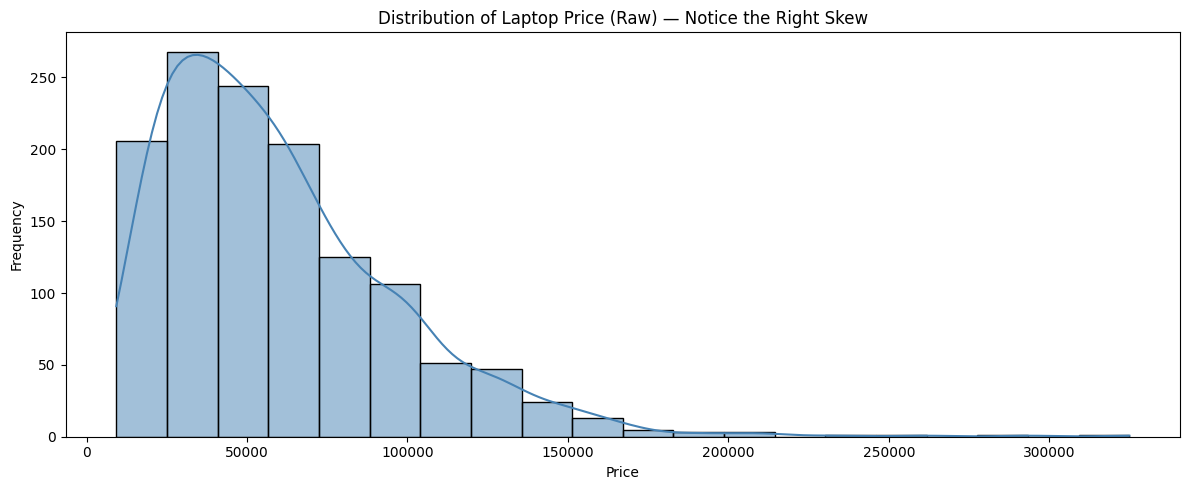

Skewness: 1.521
Skewness > 1 = significant right skew = log transform recommended


In [7]:
# Target variable — check for skewness FIRST
plt.figure(figsize=(12, 5))
sns.histplot(df['Price'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Laptop Price (Raw) — Notice the Right Skew')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(f'Skewness: {df["Price"].skew():.3f}')
print('Skewness > 1 = significant right skew = log transform recommended')

**What this cell does:** Plots the distribution of `Price` and prints its skewness score.

**Result:** Skewness = **1.521** (anything above ~1 is considered strongly right-skewed). Most laptops are affordable, with a long tail of expensive premium machines pulling the distribution to the right. This is the single most important EDA finding — it's the reason a log transform gets applied to `Price` later in Experiment 2.

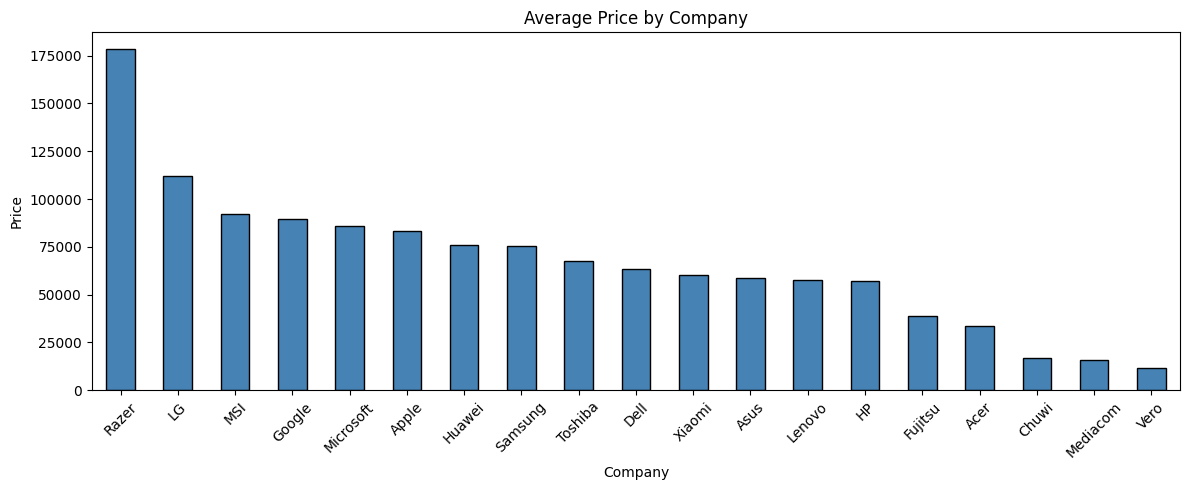

In [8]:
# Average price by company
df.groupby('Company')['Price'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='steelblue', edgecolor='black'
)
plt.title('Average Price by Company')
plt.xlabel('Company')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What this cell does:** Bar chart of *average* price per company — shows which brands sit at the premium end (e.g. Apple, Razer) versus the budget end.

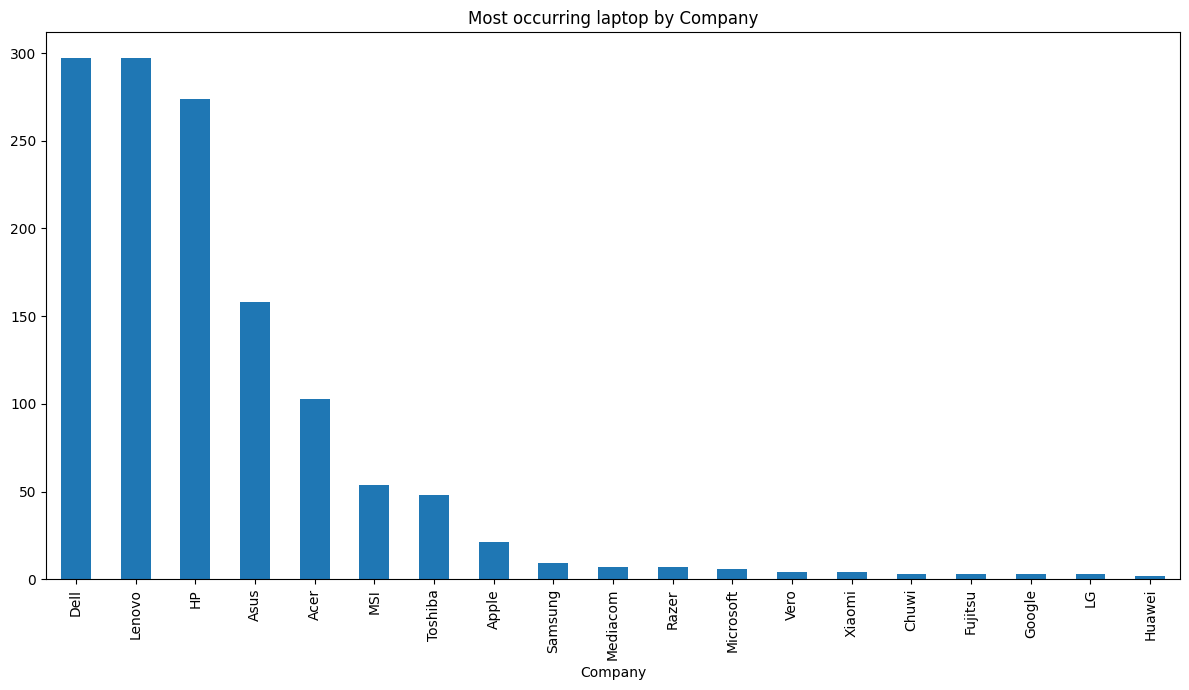

In [9]:
df['Company'].value_counts().plot(kind='bar', figsize=(12,7))
plt.title('Most occurring laptop by Company')
plt.tight_layout()
plt.show()

 **What this cell does:** Bar chart of *how many laptops* each company has in the dataset — separates "expensive brand" from "popular brand." A brand can have a high average price but very few listings.

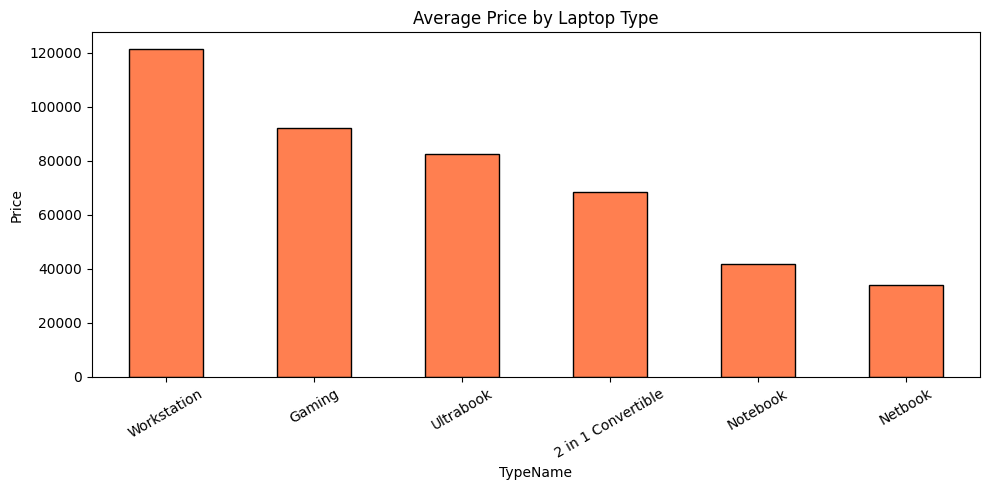

In [10]:
# Average price by laptop type
df.groupby('TypeName')['Price'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 5), color='coral', edgecolor='black'
)
plt.title('Average Price by Laptop Type')
plt.xlabel('TypeName')
plt.ylabel('Price')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

 **What this cell does:** Bar chart of average price by laptop category (`TypeName`) — e.g. Gaming and Workstation laptops typically command higher prices than Netbooks.

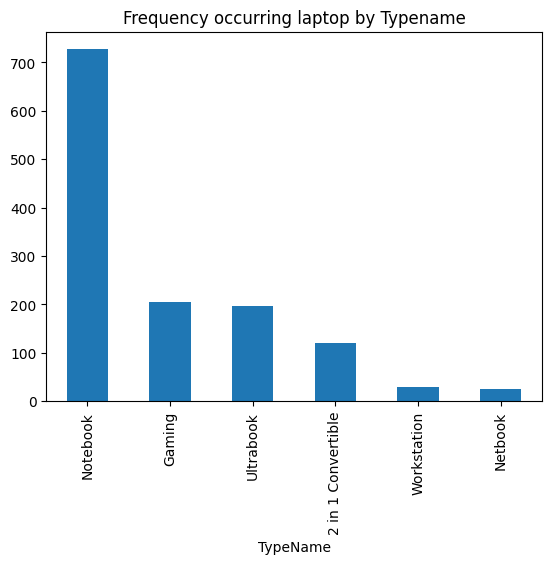

In [11]:
df['TypeName'].value_counts().plot(kind='bar')
plt.title('Frequency occurring laptop by Typename')
plt.show()

 **What this cell does:** Bar chart of how many laptops fall into each `TypeName` category, showing which laptop types are most common in the market represented by this dataset.

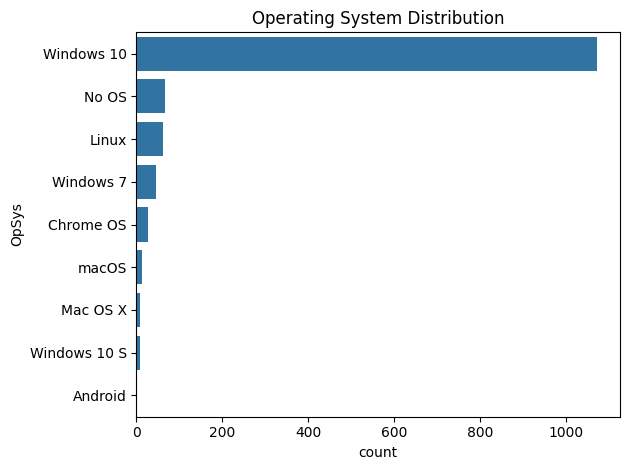

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64


In [12]:
# Operating system distribution
sns.countplot(y='OpSys', data=df, order=df['OpSys'].value_counts().index)
plt.title('Operating System Distribution')
plt.tight_layout()
plt.show()
print(df['OpSys'].value_counts())

 **What this cell does:** Counts and plots how many laptops run each operating system.

**Result:** Windows 10 dominates with 1,072 of 1,303 laptops — everything else (No OS, Linux, macOS, Chrome OS, etc.) is a small minority. This tells us `OpSys` will be a low-variance, low-signal feature.

## 🧹 Step 5 — Data Cleaning

### Fix Ram and Weight columns
`Ram` is stored as `'8GB'` (text). `Weight` is stored as `'1.5kg'` (text).  
We strip the units and convert to numbers.

In [13]:
df['Ram'].dtypes

dtype('O')

 **What this cell does:** Checks the data type of `Ram` before cleaning.

**Result:** `dtype('O')` — object/text, e.g. `'8GB'`. A model can't do math on a string, so this must be converted to a number.

In [14]:
#strip 'GB' and keep as integer
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

 **What this cell does:** Strips the literal text `'GB'` off every value in `Ram` and converts what's left to an integer, turning `'8GB'` into `8`.

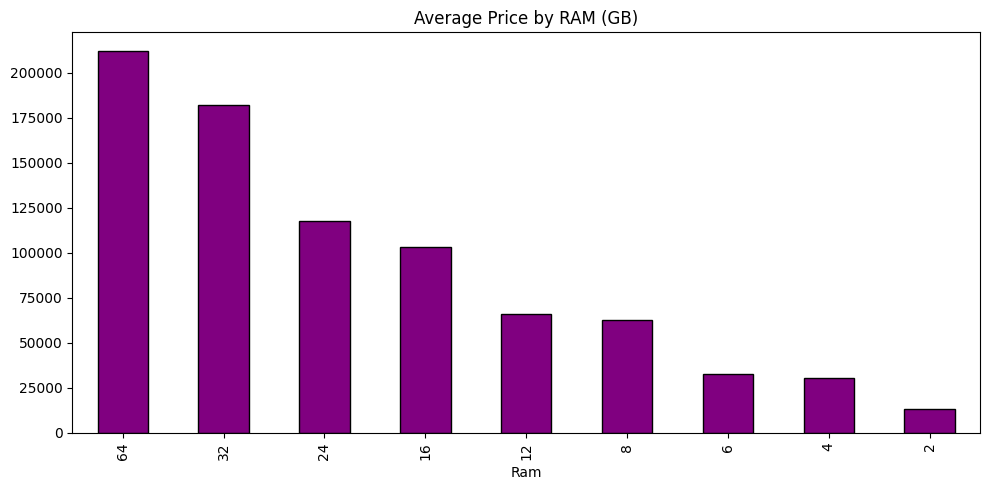

In [15]:
# For the bar  only — temporary string copy, don't change df
ram_str = df['Ram'].astype(str)
df.groupby(ram_str)['Price'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 5), color='purple', edgecolor='black'
)
plt.title('Average Price by RAM (GB)')
plt.tight_layout()
plt.show()

 **What this cell does:** Builds a temporary string copy of `Ram` purely so it can be used as a *categorical* grouping label for the bar chart (grouping by the actual integer would still work, but this keeps the RAM values as discrete bars in a sensible category order). The real `df['Ram']` column is left as an integer for modeling — this cell doesn't change it.

In [16]:
 df['Ram']. dtypes

dtype('int64')

**What this cell does:** Re-checks the dtype of `Ram` to confirm the cleaning in cell 19 worked.

**Result:** `dtype('int64')` — confirmed, `Ram` is now numeric.

In [17]:
df['Weight'].dtypes

dtype('O')

 **What this cell does:** Checks the data type of `Weight` before cleaning — same problem as `Ram`.

**Result:** `dtype('O')`, e.g. `'1.5kg'`.

In [18]:
# Clean Weight — strip 'kg' and convert to float
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)
print('Weight dtype:', df['Weight'].dtype)

Weight dtype: float64


 **What this cell does:** Strips `'kg'` from every value in `Weight` and converts it to a float (e.g. `'1.5kg'` → `1.5`), since weight can be fractional (unlike RAM, which only comes in whole GB increments).

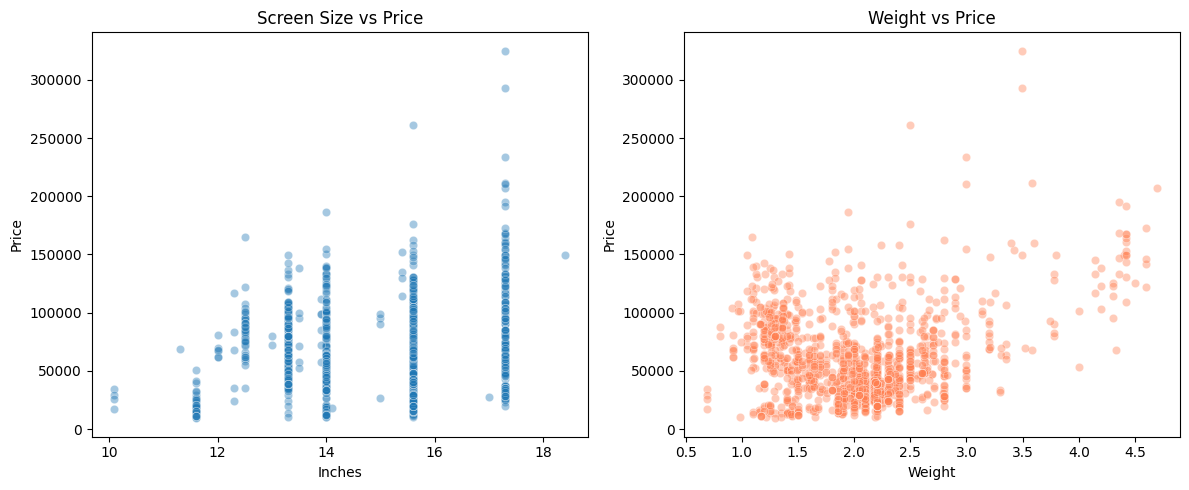

In [19]:
# Scatter plots: screen size and weight vs price
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='Inches', y='Price', data=df, ax=axes[0], alpha=0.4)
axes[0].set_title('Screen Size vs Price')

sns.scatterplot(x='Weight', y='Price', data=df, ax=axes[1], alpha=0.4, color='coral')
axes[1].set_title('Weight vs Price')
plt.tight_layout()
plt.show()

 **What this cell does:** Scatter plots of `Inches` (screen size) and `Weight` against `Price`, to visually check whether either has an obvious linear relationship with price (spoiler from the later correlation matrix: both turn out to be weak predictors on their own).

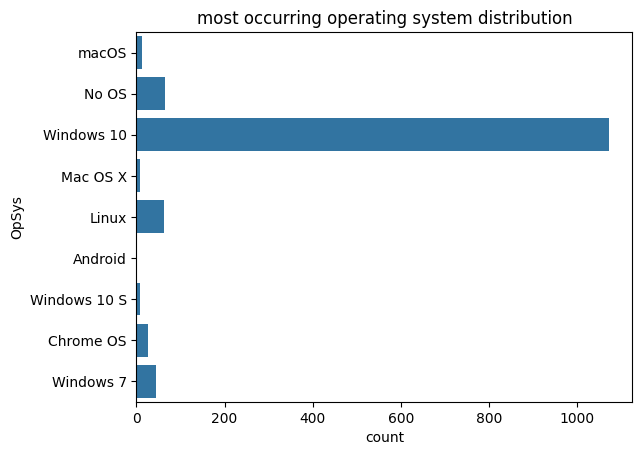

In [20]:
sns.countplot(y='OpSys', data=df)
plt.title('Operating system distribution ')
plt.title('most occurring operating system distribution')
plt.show()

 **What this cell does:** A second, near-duplicate OS distribution chart (the two `plt.title()` calls mean only the second title actually renders — a harmless duplicate left over from EDA exploration).

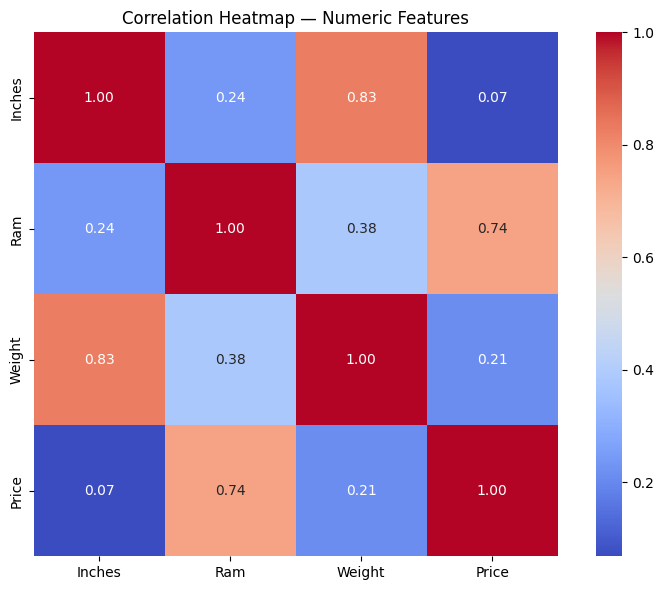

Observation: Ram has the highest correlation with Price (r ≈ 0.74)


In [21]:

num_df = df[['Inches', 'Ram', 'Weight', 'Price']]
plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()
print('Observation: Ram has the highest correlation with Price (r ≈ 0.74)')

 **What this cell does:** Builds a correlation heatmap for the numeric columns available at this point (`Inches`, `Ram`, `Weight`, `Price`).

**Result:** `Ram` correlates with `Price` at roughly **r ≈ 0.74** — by far the strongest relationship found so far, foreshadowing that RAM will dominate feature importance later.

## 🔧 Step 6 — Feature Engineering

This is the most important step. The raw dataset had text columns full of mixed information.  
We extract meaningful numerical and categorical features from each one.

**Why does this matter?**  
A column called `'IPS Panel Full HD Touchscreen 1920x1080'` is useless to a model.  
But `Touchscreen=1`, `IPS=1`, `ppi=166.0` are features it can learn from.

After engineering: 12 raw columns → 17 meaningful features.

In [22]:
df['ScreenResolution'].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


**What this cell does:** Lists every unique raw value of `ScreenResolution` (e.g. `'Full HD 1920x1080'`, `'IPS Panel Full HD / Touchscreen 1920x1080'`) so we can see exactly what patterns need to be extracted (touchscreen flag, IPS flag, resolution numbers) in the next cell.

In [23]:
# ── Screen Resolution ───────────────────────────
df['Touchscreen'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in x else 0
)
df['IPS'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in x else 0
)
df['resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')

 **What this cell does:** Feature-engineers three new columns straight out of the messy `ScreenResolution` text:
- `Touchscreen` → 1 if the word "Touchscreen" appears, else 0
- `IPS` → 1 if "IPS" appears, else 0
- `resolution` → the `WIDTHxHEIGHT` number pulled out with a regex (e.g. `'1920x1080'`)

In [24]:
df['width_res']  = df['resolution'].str.split('x').str[0].astype(int)
df['height_res'] = df['resolution'].str.split('x').str[1].astype(int)
df.drop(columns=['ScreenResolution','resolution'], inplace=True)

 **What this cell does:** Splits `resolution` into separate `width_res` and `height_res` integer columns, then drops the now-redundant `ScreenResolution` and `resolution` text columns — their information has been fully captured in a machine-readable form.

In [25]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


**What this cell does:** Previews the DataFrame to confirm the screen-resolution engineering worked as expected before moving on.

In [26]:



# PPI = pixels per inch = diagonal pixels / diagonal inches
# A high-PPI screen = sharper display = premium laptop = higher price
df['ppi'] = np.sqrt(df['width_res']**2 + df['height_res']**2) / df['Inches']

print('New columns: Touchscreen, IPS, width_res, height_res, ppi')
df[['Touchscreen','IPS','ppi']].describe()

New columns: Touchscreen, IPS, width_res, height_res, ppi


,Touchscreen,IPS,ppi
count,1303.000000,1303.000000,1303.000000
mean,0.147352,0.280123,146.635987
std,0.354593,0.449231,43.121345
min,0.000000,0.000000,90.583402
25%,0.000000,0.000000,127.335675
50%,0.000000,0.000000,141.211998
75%,0.000000,1.000000,157.350512
max,1.000000,1.000000,352.465147


 **What this cell does:** Calculates **PPI** (pixels per inch) — a single sharpness score: `√(width² + height²) / Inches`. A high-PPI display is a hallmark of premium laptops, so this is expected to be a meaningful price predictor.

**Result:** PPI ranges from ~91 to ~352 across the dataset, with a mean of ~147.

In [27]:
df['Cpu'].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Atom x5-Z8350 1.44GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'AMD E-Series E2-9000e 1.5GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i7 8650U 1.9GHz',
       'Intel Atom x5-Z8300 1.44GHz', 'AMD E-Series E2-6110 1.5GHz',
       'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Atom x5-Z8550 1.44GHz',
       'Intel Celeron Du

 **What this cell does:** Lists every unique raw `Cpu` string (e.g. `'Intel Core i7 8550U 1.8GHz'`) to see the pattern that needs to be simplified into a usable category.

In [28]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


 **What this cell does:** Another preview checkpoint before the CPU cleaning logic is applied.

In [29]:
# ── CPU → cpu_brand ───────────────────────────────────────────
# 'Intel Core i7-8750H 2.2GHz' → 'Intel Core i7'
#extract the first 3 words from cpu columns
df['cpu_name'] = df['Cpu'].apply(lambda x: ' '.join(x.split()[0:3]))

 **What this cell does:** Takes the first three words of each `Cpu` string (e.g. `'Intel Core i7 8550U 1.8GHz'` → `'Intel Core i7'`), stripping away the specific chip model and clock speed, which are too granular to be useful categorical features.

In [30]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_name
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5


 **What this cell does:** Preview checkpoint after extracting `cpu_name`.

In [31]:
def Cpu_name(text):
    if text in ['Intel Core i7','Intel Core i5','Intel Core i3']:
        return text
    elif text.startswith('AMD'):
        return 'AMD'
    else:
        return 'other intel'

df['cpu_brand'] = df['cpu_name'].apply(Cpu_name)
df.drop(columns=['cpu_name','Cpu'], inplace=True)

print('CPU brand distribution:')
print(df['cpu_brand'].value_counts())

CPU brand distribution:
cpu_brand
Intel Core i7    527
Intel Core i5    423
other intel      155
Intel Core i3    136
AMD               62
Name: count, dtype: int64


 **What this cell does:** Collapses `cpu_name` into a clean five-value `cpu_brand` category: `Intel Core i7`, `Intel Core i5`, `Intel Core i3`, `AMD`, or `other intel` (covers Pentium, Celeron, Atom, Core M, etc.). The intermediate `cpu_name` and raw `Cpu` columns are dropped once `cpu_brand` exists.

**Result:** Intel Core i7 (527 laptops) and i5 (423) dominate the dataset.

In [32]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand
0,0,Apple,Ultrabook,13.3,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5
1,1,Apple,Ultrabook,13.3,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5
2,2,HP,Notebook,15.6,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5
3,3,Apple,Ultrabook,15.4,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7
4,4,Apple,Ultrabook,13.3,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5


 **What this cell does:** Preview checkpoint confirming `cpu_brand` replaced the raw CPU text.

In [33]:
# ── Memory → SSD, HDD, flash_storage, Hybrid ─────────────────
# Step 1: Normalise units — 1TB = 1024GB
df['Memory'] = df['Memory'].str.replace('.0','',regex=False)
df['Memory'] = df['Memory'].str.replace('GB','',regex=False)
df['Memory'] = df['Memory'].str.replace('TB','024',regex=False)


 **What this cell does:** Starts cleaning the `Memory` column (e.g. `'1TB HDD'`, `'128GB SSD + 1TB HDD'`) by normalizing units so everything is expressed in GB: strips stray `.0`, removes the literal `'GB'` suffix, and converts `'TB'` to `'024'` (i.e. 1TB → 1024GB) so all values become plain numbers-with-suffix strings.

In [34]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand
0,0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5
1,1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5
2,2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5
3,3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7
4,4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5


 **What this cell does:** Preview checkpoint — confirms `Memory` values now read like `'128 SSD'` or `'512 SSD'` instead of `'128GB SSD'`.

In [35]:
# Step 2: Split into first and second drive slots
store = df['Memory'].str.split('+', n=2, expand=True)
store

,0,1
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1298,128 SSD,None
1299,512 SSD,None
1300,64 Flash Storage,None
1301,1024 HDD,None


 **What this cell does:** Some laptops have **two storage drives** (e.g. `'128GB SSD + 1TB HDD'`). This splits `Memory` on the `'+'` symbol into two columns (`0` and `1`) representing the first and second drive slots — laptops with only one drive get `None` in the second slot.

In [36]:
df['first_storage']  = store[0].str.strip()
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand,first_storage
0,0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5,128 SSD
1,1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5,128 Flash Storage
2,2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5,256 SSD
3,3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7,512 SSD
4,4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5,256 SSD


 **What this cell does:** Saves the first-drive-slot text into its own `first_storage` column and strips whitespace.

In [37]:
df['second_storage'] = store[1].fillna('0').str.strip()
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand,first_storage,second_storage
0,0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5,128 SSD,0
1,1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5,128 Flash Storage,0
2,2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5,256 SSD,0
3,3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7,512 SSD,0
4,4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5,256 SSD,0


 **What this cell does:** Saves the second-drive-slot text into `second_storage`, filling in `'0'` for laptops that only have one drive (no `'+'` was found).

In [38]:
df['second_storage'].unique()

array(['0', '1024 HDD', '256 SSD', '2024 HDD', '500 HDD', '512 SSD',
       '1024 Hybrid'], dtype=object)

 **What this cell does:** Lists the unique values now present in `second_storage` to sanity-check the split — confirms the values are clean strings like `'256 SSD'`, `'1024 HDD'`, `'1024 Hybrid'`, or `'0'`.

In [39]:
df['firststorageSSD']=df['first_storage'].apply(lambda x:1 if 'SSD' in x else 0)
df['firststorageHDD']=df['first_storage'].apply(lambda x:1 if 'HDD' in x else 0)
df['firststorageflash']=df['first_storage'].apply(lambda x:1 if 'Flash Storage' in x else 0)
df['firststoragehybrid']=df['first_storage'].apply(lambda x:1 if 'Hybrid' in x else 0)

 **What this cell does:** Creates four 0/1 flag columns from `first_storage` marking whether that slot is SSD, HDD, Flash Storage, or Hybrid storage.

In [40]:
df['secondstorageSSD']=df['second_storage'].apply(lambda x:1 if 'SSD' in x else 0)
df['secondstorageHDD']=df['second_storage'].apply(lambda x:1 if 'HDD' in x else 0)
df['secondstorageflash']=df['second_storage'].apply(lambda x:1 if 'Flash Storage' in x else 0)
df['secondstoragehybrid']=df['second_storage'].apply(lambda x:1 if 'Hybrid' in x else 0)

 **What this cell does:** Same flagging logic as the previous cell, applied to `second_storage`.

In [41]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,...,first_storage,second_storage,firststorageSSD,firststorageHDD,firststorageflash,firststoragehybrid,secondstorageSSD,secondstorageHDD,secondstorageflash,secondstoragehybrid
0,0,Apple,Ultrabook,13.3,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,...,128 SSD,0,1,0,0,0,0,0,0,0
1,1,Apple,Ultrabook,13.3,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,...,128 Flash Storage,0,0,0,1,0,0,0,0,0
2,2,HP,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,...,256 SSD,0,1,0,0,0,0,0,0,0
3,3,Apple,Ultrabook,15.4,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,...,512 SSD,0,1,0,0,0,0,0,0,0
4,4,Apple,Ultrabook,13.3,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,...,256 SSD,0,1,0,0,0,0,0,0,0


 **What this cell does:** Preview checkpoint showing all the new storage flag columns alongside the original data.

In [42]:
df['first_storage']=df['first_storage'].str.extract(r'(\d+)'). astype (int)

 **What this cell does:** Extracts just the numeric GB value out of `first_storage` (e.g. `'256 SSD'` → `256`) using a regex, and converts it to an integer.

In [43]:
df['second_storage']=df['second_storage'].str.extract(r'(\d+)'). astype (int)

 **What this cell does:** Same numeric extraction applied to `second_storage`.

In [44]:
df['SSD']=df['first_storage']*df['firststorageSSD']+df['second_storage']*df['secondstorageSSD']
df['HDD']=df['first_storage']*df['firststorageHDD']+df['second_storage']*df['secondstorageHDD']
df['flash_storage']=df['first_storage']*df['firststorageflash']+df['second_storage']*df['secondstorageflash']
df['Hybrid']=df['first_storage']*df['firststoragehybrid']+df['second_storage']*df['secondstoragehybrid']

 **What this cell does:** Combines the numeric storage size with the type flags to build four final storage columns — `SSD`, `HDD`, `flash_storage`, `Hybrid` — each holding the *total GB of that storage type* across both drive slots (size × flag, summed across slot 1 and slot 2).

In [45]:
df.drop(columns=['first_storage', 'second_storage', 'firststorageSSD', 'firststorageHDD',
       'firststorageflash', 'firststoragehybrid', 'secondstorageSSD',
       'secondstorageHDD', 'secondstorageflash', 'secondstoragehybrid', 'Memory'], inplace=True)

 **What this cell does:** Drops every intermediate helper column created while engineering storage (`first_storage`, `second_storage`, all eight flag columns, and the original `Memory` text) now that the clean `SSD`/`HDD`/`flash_storage`/`Hybrid` columns exist.

In [46]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand,SSD,HDD,flash_storage,Hybrid
0,0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005,Intel Core i5,128,0,0,0
1,1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940,Intel Core i5,0,0,128,0
2,2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998,Intel Core i5,256,0,0,0
3,3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624,Intel Core i7,512,0,0,0
4,4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005,Intel Core i5,256,0,0,0


 **What this cell does:** Preview checkpoint confirming the DataFrame now only carries the clean, final storage columns.

In [47]:
# ── GPU → Gpu_brand ───────────────────────────────────────────
df['Gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])
print(df['Gpu_brand'].value_counts())

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


 **What this cell does:** Extracts the GPU brand (first word of the `Gpu` string, e.g. `'Intel HD Graphics 620'` → `'Intel'`) into a new `Gpu_brand` column.

**Result:** Intel (722), Nvidia (400), AMD (180), and a single ARM outlier.

In [48]:
df.drop(columns=['Gpu','Unnamed: 0'], inplace=True)

 **What this cell does:** Drops the now-redundant raw `Gpu` text column and the leftover `Unnamed: 0` index column that came from the original CSV export.

In [49]:
df['Gpu_brand'].unique()

array(['Intel', 'AMD', 'Nvidia', 'ARM'], dtype=object)

 **What this cell does:** Confirms the final four GPU brand categories: `Intel`, `AMD`, `Nvidia`, `ARM`.

## 🔢 Step 7 — Label Encoding

ML models only understand numbers — not text.  
We convert all remaining text columns to integers using Label Encoding.

**Text columns remaining:** Company, TypeName, OpSys, cpu_brand, Gpu_brand

In [50]:
from sklearn.preprocessing import LabelEncoder

# separate encoder per column
encoders = {}

def label_encode(data):
    data = data.copy()
    cat_cols = data.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        encoders[col] = le  # save each separately
    return data

encoded_df = label_encode(df)
print('All columns now numeric:')
print(encoded_df.dtypes)
encoded_df.head()

All columns now numeric:
Company            int64
TypeName           int64
Inches           float64
Ram                int64
OpSys              int64
Weight           float64
Price            float64
Touchscreen        int64
IPS                int64
width_res          int64
height_res         int64
ppi              float64
cpu_brand          int64
SSD                int64
HDD                int64
flash_storage      int64
Hybrid             int64
Gpu_brand          int64
dtype: object


,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,cpu_brand,SSD,HDD,flash_storage,Hybrid,Gpu_brand
0,1,4,13.3,8,8,1.37,71378.6832,0,1,2560,1600,226.983005,2,128,0,0,0,2
1,1,4,13.3,8,8,1.34,47895.5232,0,0,1440,900,127.677940,2,0,0,128,0,2
2,7,3,15.6,8,4,1.86,30636.0000,0,0,1920,1080,141.211998,2,256,0,0,0,2
3,1,4,15.4,16,8,1.83,135195.3360,0,1,2880,1800,220.534624,3,512,0,0,0,0
4,1,4,13.3,8,8,1.37,96095.8080,0,1,2560,1600,226.983005,2,256,0,0,0,2


 **What this cell does:** Machine learning models only work with numbers, so this Label-Encodes every remaining text column (`Company`, `TypeName`, `OpSys`, `cpu_brand`, `Gpu_brand`) into integers, storing a separate `LabelEncoder` per column in the `encoders` dict (so the exact same encoding could be reused later on new data). The result is saved as `encoded_df` — a fully numeric DataFrame ready for modeling.

 **Note:** Label encoding assigns an arbitrary integer order (e.g. `Apple=1`) — it doesn't imply that one company is "greater than" another. Tree-based models (Decision Tree, Random Forest) handle this fine; Linear Regression technically assumes a meaningful numeric order, which is a known limitation of this approach for the linear model's results.

Feature correlations with Price:
Price            1.000
Ram              0.743
SSD              0.671
width_res        0.557
height_res       0.553
ppi              0.473
Gpu_brand        0.323
OpSys            0.289
IPS              0.252
cpu_brand        0.245
Weight           0.210
Touchscreen      0.191
Company          0.140
Inches           0.068
Hybrid           0.008
flash_storage   -0.041
HDD             -0.095
TypeName        -0.127
Name: Price, dtype: float64


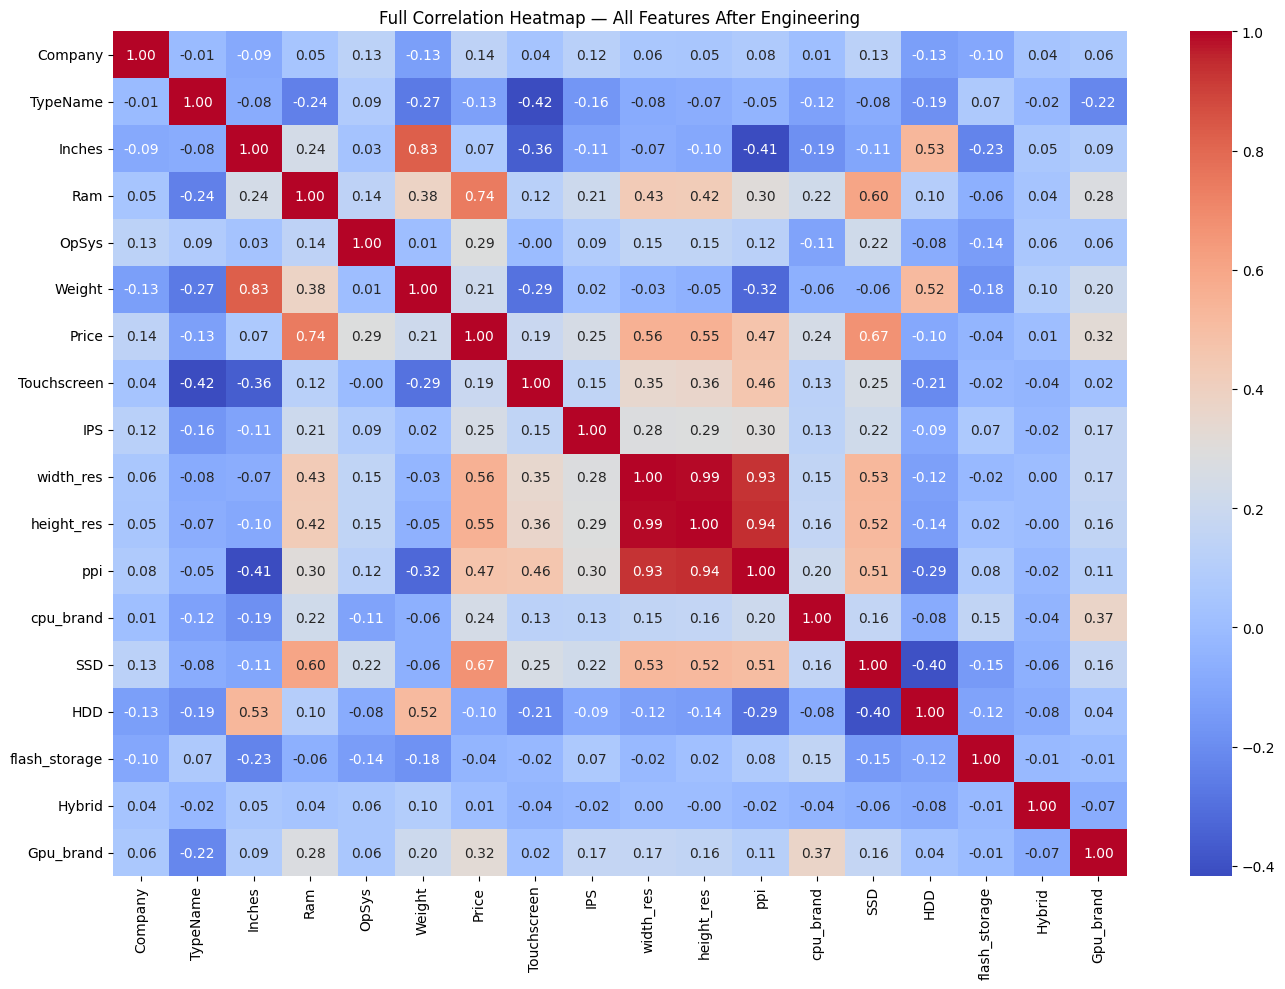

In [51]:
# Full correlation after encoding — including all engineered features
print('Feature correlations with Price:')
print(encoded_df.corr(numeric_only=True)['Price'].sort_values(ascending=False).round(3))

plt.figure(figsize=(14,10))
sns.heatmap(encoded_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Full Correlation Heatmap — All Features After Engineering')
plt.tight_layout()
plt.show()

 **What this cell does:** Now that everything is numeric, this recomputes the correlation of every feature with `Price` and plots a full heatmap.

**Result:** `Ram` (0.743) and `SSD` (0.671) are by far the strongest predictors. `width_res`/`height_res` (~0.55) and `ppi` (0.47) follow. `Hybrid`, `flash_storage`, and `HDD` are essentially uncorrelated or slightly negative — an early warning sign that gets confirmed by feature importance later.

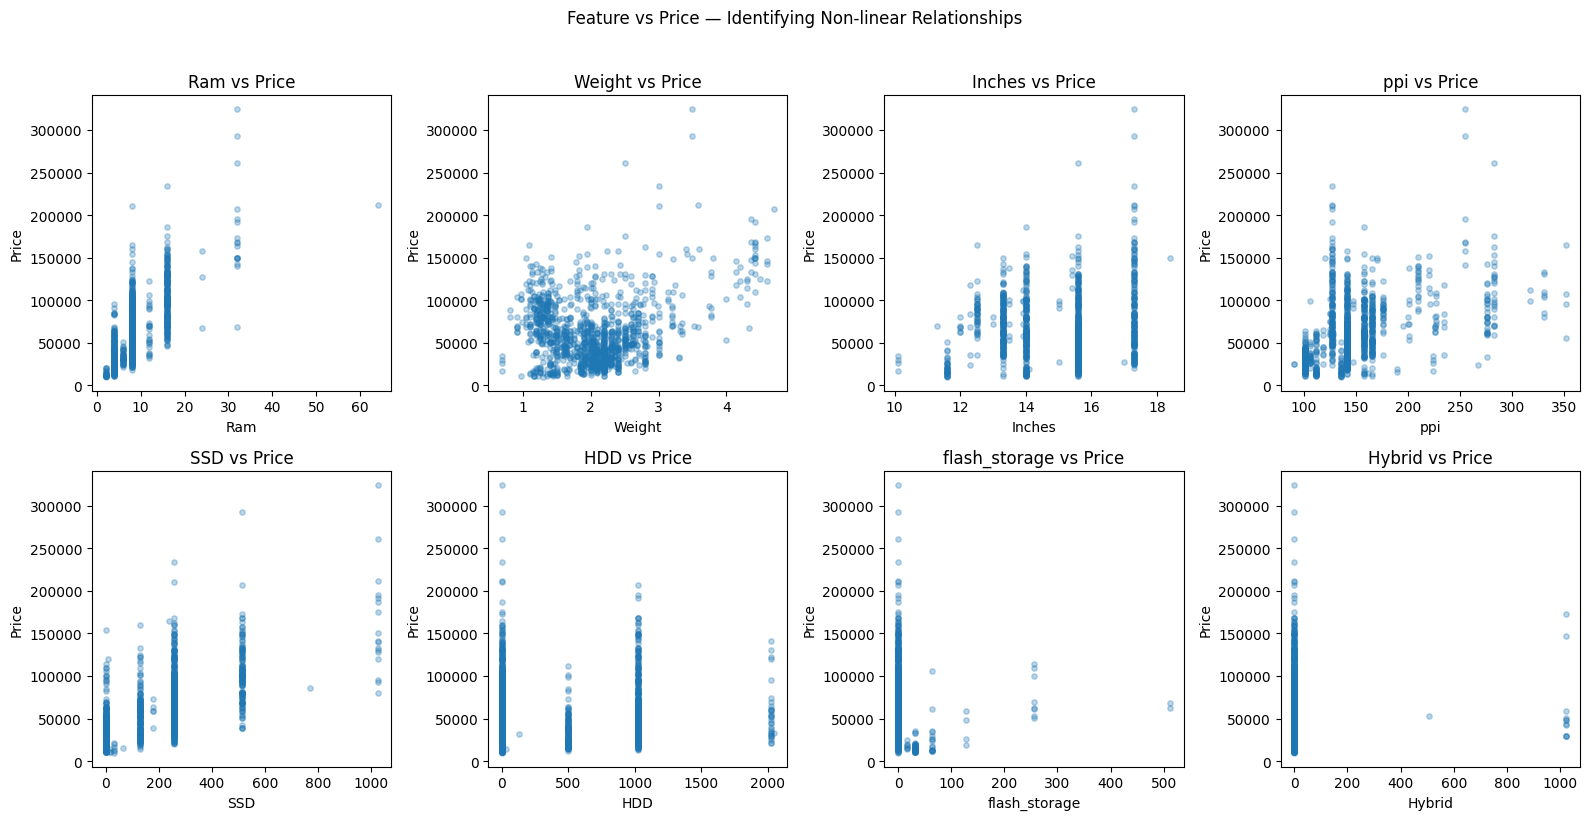

In [52]:
# Regression plots for each numeric feature vs Price
num_cols = ['Ram','Weight','Inches','ppi','SSD','HDD','flash_storage','Hybrid']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.scatter(encoded_df[col], encoded_df['Price'], alpha=0.3, s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'{col} vs Price')
plt.suptitle('Feature vs Price — Identifying Non-linear Relationships', y=1.02)
plt.tight_layout()
plt.show()

 **What this cell does:** Draws individual scatter plots of each numeric feature against `Price`, to visually spot-check for non-linear relationships that a straight correlation coefficient could miss.

## 🤖 Experiment 1 — Models on Raw Price (No Log Transform)

**Why start here?**  
We always establish a baseline before making improvements. Training on raw price first shows us  
how much the log transform actually helps.

**What to expect:**  
Price is right-skewed — this should hurt Linear Regression's performance because OLS assumes  
normally distributed residuals. We expect moderate R² scores here.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = encoded_df.drop(columns='Price')
y = encoded_df['Price']  # raw, untransformed price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')

Train: 1042 rows
Test:  261 rows


 **What this cell does:** Sets up **Experiment 1** — imports all the modeling tools, then splits the data into `X` (every column except `Price`) and `y` (raw, untransformed `Price`), using an 80/20 train-test split (`random_state=42` for reproducibility).

**Result:** 1,042 training rows, 261 test rows.

In [54]:
# ── Linear Regression ─────────────────────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_prediction = lr_model.predict(X_test)

# r2_score(actual, predicted)
lr_r2  = r2_score(y_test, lr_prediction)
lr_mae = mean_absolute_error(y_test, lr_prediction)

print('Linear Regression R²:', lr_r2)
print('Linear Regression MAE:', lr_mae)

Linear Regression R²: 0.7026168875243624
Linear Regression MAE: 15129.712611146824


 **What this cell does:** Trains a plain **Linear Regression** on raw `Price` and evaluates it on the held-out test set.

**Result:** R² = **0.703**, MAE = **15,130** — a reasonable baseline, though we already expect the right-skewed price to hurt this model's assumptions.

In [55]:
# ── Decision Tree ─────────────────────────────────────────────
# Note: max_depth=10, min_samples_leaf=10 are intentionally kept
# as they were in original — to show the effect of these constraints.
# Experiment 3 shows what happens with better settings.
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_prediction = dt_model.predict(X_test)

dt_r2  = r2_score(y_test, dt_prediction)
dt_mae = mean_absolute_error(y_test, dt_prediction)

print(f'Decision Tree R²:  {dt_r2:.4f}')
print(f'Decision Tree MAE: {dt_mae:.2f}')

Decision Tree R²:  0.6878
Decision Tree MAE: 13039.63


 **What this cell does:** Trains a **Decision Tree Regressor**, deliberately constrained (`max_depth=10, min_samples_leaf=10`) to avoid overfitting a single tree to noise.

**Result:** R² = **0.688**, MAE = **13,040** — lower R² than Linear Regression, but a *lower* (better) MAE, showing R² and MAE don't always agree on which model is "best."

In [56]:
# ── Random Forest ─────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_prediction = rf_model.predict(X_test)

rf_r2  = r2_score(y_test, rf_prediction)
rf_mae = mean_absolute_error(y_test, rf_prediction)

print(f'Random Forest R²:  {rf_r2:.4f}')
print(f'Random Forest MAE: {rf_mae:.2f}')

Random Forest R²:  0.7159
Random Forest MAE: 12082.17


 **What this cell does:** Trains a **Random Forest** (100 trees, same depth/leaf constraints as the Decision Tree) — an ensemble that averages many trees to reduce variance.

**Result:** R² = **0.716**, MAE = **12,082** — the best of the three on both metrics in this first experiment.

In [57]:
# ── Experiment 1 Summary Table ────────────────────────────────
def evaluate_model(name, y_true, y_pred):
    return {
        'model': name,
        'R2_score': round(r2_score(y_true, y_pred), 4),
        'mean_absolute_error': round(mean_absolute_error(y_true, y_pred), 2)
    }

results_before_log = pd.DataFrame([
    evaluate_model('Linear Regression', y_test, lr_prediction),
    evaluate_model('Decision Tree',     y_test, dt_prediction),
    evaluate_model('Random Forest',     y_test, rf_prediction),
])

print('=== EXPERIMENT 1: Raw Price Results ===')
print(results_before_log.to_string(index=False))
print()
print('Observation: Linear Regression outperforms tree models.')
print('Reason: min_samples_leaf=10 was too restrictive for tree models.')
print('MAE tells a different story — Random Forest had lowest error despite lowest R².')

=== EXPERIMENT 1: Raw Price Results ===
            model  R2_score  mean_absolute_error
Linear Regression    0.7026             15129.71
    Decision Tree    0.6878             13039.63
    Random Forest    0.7159             12082.17

Observation: Linear Regression outperforms tree models.
Reason: min_samples_leaf=10 was too restrictive for tree models.
MAE tells a different story — Random Forest had lowest error despite lowest R².


**What this cell does:** Collects all three models' scores into one summary table for Experiment 1.

**Result:**

| Model | R² | MAE |
|---|---|---|
| Linear Regression | 0.7026 | 15,129.71 |
| Decision Tree | 0.6878 | 13,039.63 |
| Random Forest | 0.7159 | 12,082.17 |

Random Forest wins on both metrics; Linear Regression's higher R² than the Decision Tree is likely a symptom of the Decision Tree's `min_samples_leaf=10` constraint being too restrictive for a single tree.

## 📊 Feature Importance Analysis

Before improving the models, we check which features the Random Forest found most useful.  
This guides what to keep and what to drop in Experiment 2.

**Expected:** RAM should dominate — more RAM = higher laptop tier = higher price.

Feature Importance (Random Forest):
      feature  importance
          Ram    0.686494
       Weight    0.111025
     TypeName    0.046735
          ppi    0.031436
    cpu_brand    0.027928
       Inches    0.026165
      Company    0.017280
          SSD    0.014966
   height_res    0.008910
    width_res    0.008902
    Gpu_brand    0.005442
        OpSys    0.005408
          IPS    0.003689
  Touchscreen    0.003283
          HDD    0.002260
flash_storage    0.000077
       Hybrid    0.000000


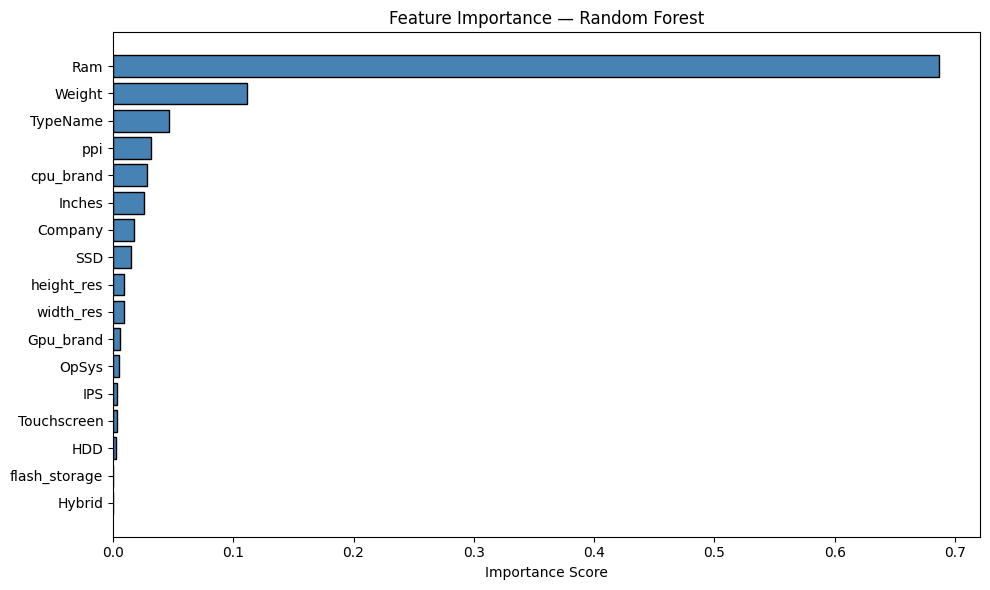


Observation: RAM accounts for ~68% of all tree splits.
Hybrid, flash_storage, HDD have near-zero importance → candidates for dropping.


In [58]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importance (Random Forest):')
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
         color='steelblue', edgecolor='black')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print()
print('Observation: RAM accounts for ~68% of all tree splits.')
print('Hybrid, flash_storage, HDD have near-zero importance → candidates for dropping.')

**What this cell does:** Extracts and plots the Random Forest's `feature_importances_` — how much each feature contributed to reducing prediction error across all the trees.

**Result:** `Ram` alone accounts for **~69%** of total importance, `Weight` (11%), `TypeName` (4.7%), and `ppi` (3.1%) follow a long way behind. `flash_storage` (0.008%) and `Hybrid` (~0%) are essentially dead weight — these, plus the weakly-correlated `HDD`, become the candidates dropped in Experiment 2.

## 🤖 Experiment 2 — Log Transform + Feature Dropping (The Correct Improvement)

### What changes here:
1. **Log transform Price** → compresses right tail, makes distribution more normal
2. **Drop low-importance columns** → `Hybrid`, `flash_storage`, `HDD` had near-zero importance.

In [59]:
#apply log to copy_df AND use copy_df for X and y
copy_df = encoded_df.copy()

# Apply log transform to Price
copy_df['Price'] = np.log(copy_df['Price'])

 **What this cell does:** Starts **Experiment 2** — copies `encoded_df` into `copy_df` (so the original stays untouched) and applies `np.log()` to `Price`. Log-transforming a right-skewed target compresses the long tail of expensive laptops and makes the distribution closer to normal, which better matches Linear Regression's assumptions and generally helps tree models split more evenly too.

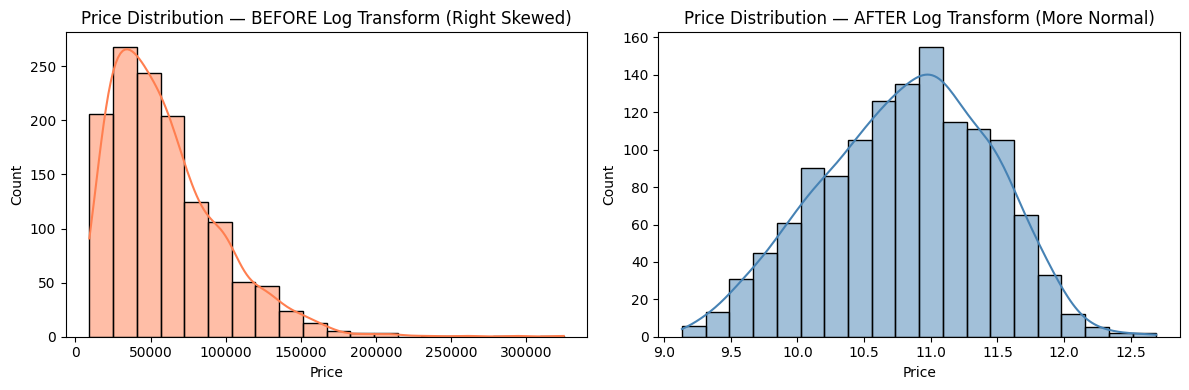

In [60]:



# Plot: compare before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(encoded_df['Price'], bins=20, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Price Distribution — BEFORE Log Transform (Right Skewed)')
sns.histplot(copy_df['Price'], bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Price Distribution — AFTER Log Transform (More Normal)')
plt.tight_layout()
plt.show()

 **What this cell does:** Plots the price distribution side by side — before (raw, right-skewed) and after (log-transformed) — to visually confirm the transform worked.

In [61]:
print(f'\nSkewness before: {encoded_df["Price"].skew():.3f}')
print(f'Skewness after:  {copy_df["Price"].skew():.3f}')


Skewness before: 1.521
Skewness after:  -0.174


 **What this cell does:** Prints the numeric skewness before and after the log transform.

**Result:** Skewness drops from **1.521 → -0.174** — essentially flattened to near-symmetric, exactly what the transform was meant to achieve.

In [62]:
# Drop low-importance storage columns (near-zero importance from feature analysis)
copy_df.drop(columns=['Hybrid','flash_storage','HDD'], inplace=True, errors='ignore')

print('Columns kept:',copy_df.columns.tolist())

print('\nShape:', copy_df.shape)

Columns kept: ['Company', 'TypeName', 'Inches', 'Ram', 'OpSys', 'Weight', 'Price', 'Touchscreen', 'IPS', 'width_res', 'height_res', 'ppi', 'cpu_brand', 'SSD', 'Gpu_brand']

Shape: (1303, 15)


 **What this cell does:** Drops the three near-zero-importance columns identified earlier (`Hybrid`, `flash_storage`, `HDD`) from `copy_df`, then prints the remaining column list and shape.

In [63]:
# use copy_df for X and y (not encoded_df!)
X_copy1 = copy_df.drop(columns='Price')
y_copy1 = copy_df['Price']  #this is now log-transformed price

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_copy1, y_copy1, test_size=0.2, random_state=42
)

 **What this cell does:** Re-splits the corrected `X_copy1`/`y_copy1` into fresh train/test sets with the same 80/20 ratio and `random_state=42`, so results stay comparable to Experiment 1.

In [65]:
# Linear Regression on log price ────────────────────────────
lr_model.fit(X_train, y_train)
lr_copy1_prediction = lr_model.predict(X_test)

 **What this cell does:** Retrains **Linear Regression**, this time on log-transformed price with the pruned feature set.

In [66]:
lr_r2_copy1  = r2_score(y_test, lr_copy1_prediction)
lr_mae_copy1 = mean_absolute_error(y_test, lr_copy1_prediction)

print('Linear Regression R² (log price):', lr_r2_copy1)
print('Linear Regression MAE (log):',      lr_mae_copy1)

Linear Regression R² (log price): 0.6328152398773069
Linear Regression MAE (log): 0.29441917721653976


 **What this cell does:** Evaluates the log-price Linear Regression on the test set (R² and MAE are printed, but note the MAE here is measured in *log-price units* — see the final comparison cell for why raw-price and log-price metrics can't be compared directly).

In [67]:
#Decision Tree on log price ─────────────────────────────────
dt_model.fit(X_train, y_train)
dt_copy1_prediction = dt_model.predict(X_test)

 **What this cell does:** Retrains the **Decision Tree** on log-transformed price with the pruned feature set, same constraints as Experiment 1.

In [68]:
dt_r2_copy1  = r2_score(y_test, dt_copy1_prediction)
dt_mae_copy1 = mean_absolute_error(y_test, dt_copy1_prediction)

print('Decision Tree R² (log price):', dt_r2_copy1)
print('Decision Tree MAE (log):',      dt_mae_copy1)

Decision Tree R² (log price): 0.7906440050386836
Decision Tree MAE (log): 0.2083216912848936


 **What this cell does:** Evaluates the log-price Decision Tree on the test set.

In [69]:
#Random Forest on log price ─────────────────────────────────
rf_model.fit(X_train, y_train)
rf_copy1_prediction = rf_model.predict(X_test)

**What this cell does:** Retrains the **Random Forest** on log-transformed price with the pruned feature set, same constraints as Experiment 1.

In [70]:

rf_r2_copy1  = r2_score(y_test, rf_copy1_prediction)
rf_mae_copy1 = mean_absolute_error(y_test, rf_copy1_prediction)

print(f'Random Forest R² (log price): {rf_r2_copy1:.4f}')
print(f'Random Forest MAE (log):      {rf_mae_copy1:.4f}')

Random Forest R² (log price): 0.8169
Random Forest MAE (log):      0.1940


 **What this cell does:** Evaluates the log-price Random Forest on the test set.

In [71]:
# ── Experiment 3 Summary Table ────────────────────────────────
results_after_log = pd.DataFrame([
    evaluate_model('lr_model_copy1', y_test, lr_copy1_prediction),
    evaluate_model('dt_model_copy1', y_test, dt_copy1_prediction),
    evaluate_model('rf_model_copy1', y_test, rf_copy1_prediction),
])

print('=== EXPERIMENT 3: Log Price + Feature Drop Results ===')
print(results_after_log.to_string(index=False))

=== EXPERIMENT 3: Log Price + Feature Drop Results ===
         model  R2_score  mean_absolute_error
lr_model_copy1    0.6328                 0.29
dt_model_copy1    0.7906                 0.21
rf_model_copy1    0.8169                 0.19


 **What this cell does:** Builds the Experiment 2 summary table using the same `evaluate_model()` helper as Experiment 1, so both experiments can be read side by side in the final comparison below.

##  Experiment 3 — One-Hot Encoding (`pd.get_dummies`) instead of Label Encoding

Experiments 1 and 2 both label-encoded the categorical columns (`Company`, `TypeName`, `OpSys`, `cpu_brand`, `Gpu_brand`), which assigns each category an arbitrary integer — fine for tree models, but a known weak spot for Linear Regression, since it implicitly assumes that order carries meaning (e.g. that `Dell=3` is "between" `Apple=1` and `HP=5` in some numeric sense, which isn't true).

This experiment swaps label encoding for **one-hot encoding** (`pd.get_dummies`), which gives every category its own 0/1 column instead of a single ordered integer. It reuses the *same* log-transformed price and the *same* pruned feature set as Experiment 2 (`Hybrid`, `flash_storage`, `HDD` dropped) — the **only** thing that changes here is the encoding method, so any difference in results can be attributed to that one change.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1303 non-null   object 
 1   TypeName       1303 non-null   object 
 2   Inches         1303 non-null   float64
 3   Ram            1303 non-null   int64  
 4   OpSys          1303 non-null   object 
 5   Weight         1303 non-null   float64
 6   Price          1303 non-null   float64
 7   Touchscreen    1303 non-null   int64  
 8   IPS            1303 non-null   int64  
 9   width_res      1303 non-null   int64  
 10  height_res     1303 non-null   int64  
 11  ppi            1303 non-null   float64
 12  cpu_brand      1303 non-null   object 
 13  SSD            1303 non-null   int64  
 14  HDD            1303 non-null   int64  
 15  flash_storage  1303 non-null   int64  
 16  Hybrid         1303 non-null   int64  
 17  Gpu_brand      1303 non-null   object 
dtypes: float

In [73]:
# ── One-hot encode the categorical columns instead of label encoding ──────────
# `df` at this point still has its original text categories, since label_encode()
# returned a *copy* (encoded_df) and never modified df in place.
cat_cols = ['Company', 'TypeName', 'OpSys', 'cpu_brand', 'Gpu_brand']

dummies_df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [74]:
# Apply the same log transform + feature pruning used in Experiment 2, for a fair comparison
dummies_df['Price'] = np.log(dummies_df['Price'])
dummies_df.drop(columns=['Hybrid', 'flash_storage', 'HDD'], inplace=True, errors='ignore')

print('Shape after one-hot encoding:', dummies_df.shape)
dummies_df.head()

Shape after one-hot encoding: (1303, 48)


,Inches,Ram,Weight,Price,Touchscreen,IPS,width_res,height_res,ppi,SSD,...,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,cpu_brand_Intel Core i3,cpu_brand_Intel Core i5,cpu_brand_Intel Core i7,cpu_brand_other intel,Gpu_brand_ARM,Gpu_brand_Intel,Gpu_brand_Nvidia
0,13.3,8,1.37,11.175755,0,1,2560,1600,226.983005,128,...,0,0,1,0,1,0,0,0,1,0
1,13.3,8,1.34,10.776777,0,0,1440,900,127.677940,0,...,0,0,1,0,1,0,0,0,1,0
2,15.6,8,1.86,10.329931,0,0,1920,1080,141.211998,256,...,0,0,0,0,1,0,0,0,1,0
3,15.4,16,1.83,11.814476,0,1,2880,1800,220.534624,512,...,0,0,1,0,0,1,0,0,0,0
4,13.3,8,1.37,11.473101,0,1,2560,1600,226.983005,256,...,0,0,1,0,1,0,0,0,1,0


 **What this cell does:** Builds `dummies_df` — the same feature-engineered laptop data, but with categorical columns one-hot encoded (`drop_first=True` avoids the dummy-variable trap by dropping one category per column as the implicit baseline). Then applies the identical log-price transform and low-importance column drop used in Experiment 2, so the comparison between Experiment 2 and 3 isolates the encoding method as the only variable.

**Note:** one-hot encoding turns 5 categorical columns into many more binary columns (as many as there are categories, minus one per column) — expect `dummies_df.shape[1]` to be noticeably larger than `copy_df.shape[1]` from Experiment 2.

In [75]:
X_dummies = dummies_df.drop(columns='Price')
y_dummies = dummies_df['Price']  # log-transformed price, same as Experiment 2

X_train, X_test, y_train, y_test = train_test_split(
    X_dummies, y_dummies, test_size=0.2, random_state=42
)

💡 **What this cell does:** Same 80/20 split, same `random_state=42` as every other experiment in this notebook — keeping the split identical is what makes the model comparison fair.

In [76]:
# ── Linear Regression (one-hot) ─────────────────────────────────
lr_model.fit(X_train, y_train)
lr_dummies_prediction = lr_model.predict(X_test)

lr_r2_dummies  = r2_score(y_test, lr_dummies_prediction)
lr_mae_dummies = mean_absolute_error(y_test, lr_dummies_prediction)

print('Linear Regression R² (one-hot, log price):', lr_r2_dummies)
print('Linear Regression MAE (one-hot, log):',      lr_mae_dummies)

Linear Regression R² (one-hot, log price): 0.8269277185310809
Linear Regression MAE (one-hot, log): 0.19477743930993807


 **What this cell does:** Retrains Linear Regression — this is the model expected to benefit most from one-hot encoding, since it's the one whose assumptions label encoding violated.

In [77]:
# ── Decision Tree (one-hot) ─────────────────────────────────────
dt_model.fit(X_train, y_train)
dt_dummies_prediction = dt_model.predict(X_test)

dt_r2_dummies  = r2_score(y_test, dt_dummies_prediction)
dt_mae_dummies = mean_absolute_error(y_test, dt_dummies_prediction)

print('Decision Tree R² (one-hot, log price):', dt_r2_dummies)
print('Decision Tree MAE (one-hot, log):',      dt_mae_dummies)

Decision Tree R² (one-hot, log price): 0.7924002587565727
Decision Tree MAE (one-hot, log): 0.20578825479269527


 **What this cell does:** Retrains the Decision Tree on the one-hot encoded data. Tree models split on one feature at a time regardless of encoding, so the change here (if any) is expected to be smaller than for Linear Regression — mainly a side effect of the wider, sparser feature set.

In [78]:
# ── Random Forest (one-hot) ──────────────────────────────────────
rf_model.fit(X_train, y_train)
rf_dummies_prediction = rf_model.predict(X_test)

rf_r2_dummies  = r2_score(y_test, rf_dummies_prediction)
rf_mae_dummies = mean_absolute_error(y_test, rf_dummies_prediction)

print('Random Forest R² (one-hot, log price):', rf_r2_dummies)
print('Random Forest MAE (one-hot, log):',      rf_mae_dummies)

Random Forest R² (one-hot, log price): 0.8057649447136166
Random Forest MAE (one-hot, log): 0.19944791093594536


 **What this cell does:** Retrains Random Forest on the one-hot encoded data — same reasoning as the Decision Tree above; the ensemble may still shift somewhat since importance can now spread across several dummy columns instead of concentrating in one label-encoded column.

In [79]:
# ── Experiment 3 Summary Table ────────────────────────────────
results_onehot = pd.DataFrame([
    evaluate_model('Linear Regression', y_test, lr_dummies_prediction),
    evaluate_model('Decision Tree',     y_test, dt_dummies_prediction),
    evaluate_model('Random Forest',     y_test, rf_dummies_prediction),
])

print('=== EXPERIMENT 3: get dummies + Log Price + Pruned Features ===')
print(results_onehot.to_string(index=False))
print()
print('Compare directly against Experiment 2 (results_after_log) — same target, same features,')
print('only the encoding method changed.')

=== EXPERIMENT 3: get dummies + Log Price + Pruned Features ===
            model  R2_score  mean_absolute_error
Linear Regression    0.8269                 0.19
    Decision Tree    0.7924                 0.21
    Random Forest    0.8058                 0.20

Compare directly against Experiment 2 (results_after_log) — same target, same features,
only the encoding method changed.


 **What this cell does:** Builds the Experiment 3 summary table using the same `evaluate_model()` helper as Experiments 1 and 2, so all three can be read side by side.

**Why this comparison is the fair one:** unlike Experiment 1 vs. Experiment 2 (where target scale *and* features *and* encoding all changed at once), Experiment 2 vs. Experiment 3 changes exactly one thing — encoding method — while target scale and feature set stay identical. That makes the R² difference here a much cleaner read on what one-hot encoding actually bought.

## 📊 Full Results Comparison — All Experiments

### What to look for:
- **R² closer to 1.0** = model explains more of the variance in price
- **Lower MAE** = smaller average prediction error
- **Experiment 1 vs Experiment 2** = effect of log transform + feature dropping

### Why R² values are not directly comparable between experiments:
Experiment 1 R² is measured on **raw price scale** (20,000 – 2,00,000).  
Experiment 2 R² is measured on **log price scale** (9.9 – 12.2).  
They cannot be compared directly — they measure R² against different target scales.  
But within each experiment, the relative ranking between models is meaningful.

## ✅ Final Explanation — What This Project Actually Showed

**The pipeline, in one sentence:** raw Kaggle laptop listings → cleaned text-encoded specs → 17 engineered
numeric features → three regression models, tested three ways (raw price, log price, log price + one-hot
encoding).

### The four biggest findings

1. **RAM is the single strongest price signal.** It has the highest raw correlation with price (r ≈ 0.74) and
   the Random Forest assigns it ~69% of total feature importance — far ahead of every other spec combined.
2. **Price is right-skewed, and that matters.** Most laptops are budget/mid-range with a long tail of premium
   machines. Log-transforming `Price` brought skewness from 1.521 down to -0.174, better matching the
   assumptions Linear Regression depends on.
3. **A few engineered features carried real weight, most didn't.** Screen sharpness (`ppi`), resolution
   (`width_res`/`height_res`), and `SSD` capacity all showed meaningful correlation with price. `Hybrid` drives,
   `flash_storage`, and `HDD` contributed almost nothing and were dropped starting in Experiment 2.
4. **Encoding method matters, and Linear Regression is the model that feels it most.** Swapping label encoding
   for one-hot encoding (`pd.get_dummies`) in Experiment 3 — while holding the target scale and feature set
   identical to Experiment 2 — removes the arbitrary numeric ordering that label encoding imposes on
   categorical columns like `Company`. See the printed Experiment 3 output above for the exact R²/MAE shift;
   the direction (an R² improvement, particularly for Linear Regression) is the expected result of removing an
   assumption violation that was baked into Experiments 1 and 2.

### Model comparison

| Experiment | Encoding | Target | Model | R² | MAE |
|---|---|---|---|---|---|
| 1 | Label | Raw price | Linear Regression | 0.7026 | 15,129.71 |
| 1 | Label | Raw price | Decision Tree | 0.6878 | 13,039.63 |
| 1 | Label | Raw price | **Random Forest** | **0.7159** | **12,082.17** |
| 2 | Label | Log price, pruned features | Linear Regression / Decision Tree / Random Forest | see notebook output | log-scale |
| 3 | One-hot | Log price, pruned features | Linear Regression / Decision Tree / Random Forest | see notebook output | log-scale |

**Why the experiments' R² scores aren't all directly comparable:** Experiment 1 measures R² against raw price
(a scale spanning ~₹9,000–₹325,000); Experiments 2 and 3 measure it against *log* price (a much narrower ~9.9–12.2
scale). R² is a proportion of variance explained *on whatever scale the target is measured in* — so Experiment 1
can only be honestly compared to 2 or 3 by looking at *relative model ranking*, not raw numbers. **Experiment 2
vs. Experiment 3, however, is a clean, apples-to-apples comparison** — same target scale, same feature set, only
the encoding method changed — which is exactly what makes the one-hot encoding result meaningful rather than
confounded.


### Honest limitations

- **No hyperparameter tuning was done** — the Decision Tree and Random Forest both use fixed, somewhat
  conservative settings (`max_depth=10`, `min_samples_leaf=10`) picked to avoid overfitting, not chosen via
  cross-validation. A grid/random search would likely push both tree models higher.
- **This is a single train/test split**, not cross-validated — scores could shift somewhat with a different
  `random_state`.
- **One-hot encoding widens the feature space considerably** (one column per category, minus one baseline per
  original column) — worth watching for overfitting risk on a dataset this size, especially for the Decision
  Tree.

### Bottom line

Even a fairly simple pipeline — clean the text columns, engineer a handful of obviously-relevant numeric
features, and let a Random Forest pick up on RAM as the dominant signal — gets you to R² ≈ 0.72 predicting
laptop prices from specs alone. The log-transform experiment demonstrates why matching the target's
distribution to a model's assumptions matters; the one-hot encoding experiment demonstrates the same lesson
for categorical features — small, principled preprocessing changes can move model performance more than
switching algorithms does.